# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 3: Achieve Best Accuracy
In the final section of the assignment, you'll take your models to the next level by modifying the model and achieving benchmark performance. You'll experiment with different architectures, hyperparameters, learning rates, and optimization techniques to achieve the best possible accuracy for object classification (CIFAR-100). Your journey will involve analyzing the impact of these changes on the models' accuracy and convergence. Feel free to write your own modules, and make changes to starter code to achieve highest possible accuracy. Results are expected to be submitted in the same format as previous sections however.

Note: You can implement one of the AlexNet, ResNet18, ResNet50, or other architectures discussed in class. However, No transfer learning or pretrained models allowed.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" {torch.cuda.get_device_name(0)}")
# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

 NVIDIA A100 80GB PCIe


In [3]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [4]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 40

In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
 # TODO: note that you want to keep
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# TODO: Initialize the model, loss function, and optimizer
model = neural_network.BetterModel(num_classes=100, in_channels=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [7]:
# TODO: Training loop
train_losses, test_losses = trainer.train(
    model, optimizer, criterion, trainloader, testloader, epochs, device, scheduler
)

Epoch 1/40 - Train Loss: 4.025232080913261
Epoch 1/40 - Test Loss: 3.673456309716913
Epoch 1/40 - Test Accuracy: 12.37%
Epoch 2/40 - Train Loss: 3.4361796385187016
Epoch 2/40 - Test Loss: 3.211721649652795
Epoch 2/40 - Test Accuracy: 20.76%
Epoch 3/40 - Train Loss: 3.009839957327489
Epoch 3/40 - Test Loss: 2.912998815126057
Epoch 3/40 - Test Accuracy: 26.47%
Epoch 4/40 - Train Loss: 2.6032629214284366
Epoch 4/40 - Test Loss: 2.6295231807081003
Epoch 4/40 - Test Accuracy: 32.93%
Epoch 5/40 - Train Loss: 2.2658694226418614
Epoch 5/40 - Test Loss: 2.458009540280209
Epoch 5/40 - Test Accuracy: 36.40%
Epoch 6/40 - Train Loss: 2.0009055607154242
Epoch 6/40 - Test Loss: 2.121112631846078
Epoch 6/40 - Test Accuracy: 43.66%
Epoch 7/40 - Train Loss: 1.8236223050700429
Epoch 7/40 - Test Loss: 2.1916624639607685
Epoch 7/40 - Test Accuracy: 43.36%
Epoch 8/40 - Train Loss: 1.692351649484366
Epoch 8/40 - Test Loss: 2.1436116046543363
Epoch 8/40 - Test Accuracy: 44.43%
Epoch 9/40 - Train Loss: 1.58794

# Visualize Final Results: Best Model - CIFAR 100

In [8]:
# Evaluate the models
accuracy = trainer.evaluate_accuracy(model, testloader, device)
train_acc = trainer.evaluate_accuracy(model, trainloader, device)
# Print test accuracy
print("C5_epochs_40 Model Test Accuracy:", accuracy)
print("C5_epochs_40 Model Train Accuracy:", train_acc)

C5_epochs_40 Model Test Accuracy: 74.83
C5_epochs_40 Model Train Accuracy: 99.71600000000001


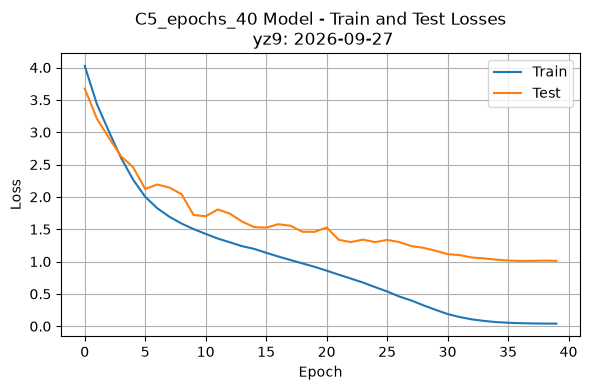

In [9]:
# Plot train and test losses
visualize.visualize_loss(train_losses, test_losses, "C5_epochs_40 Model")

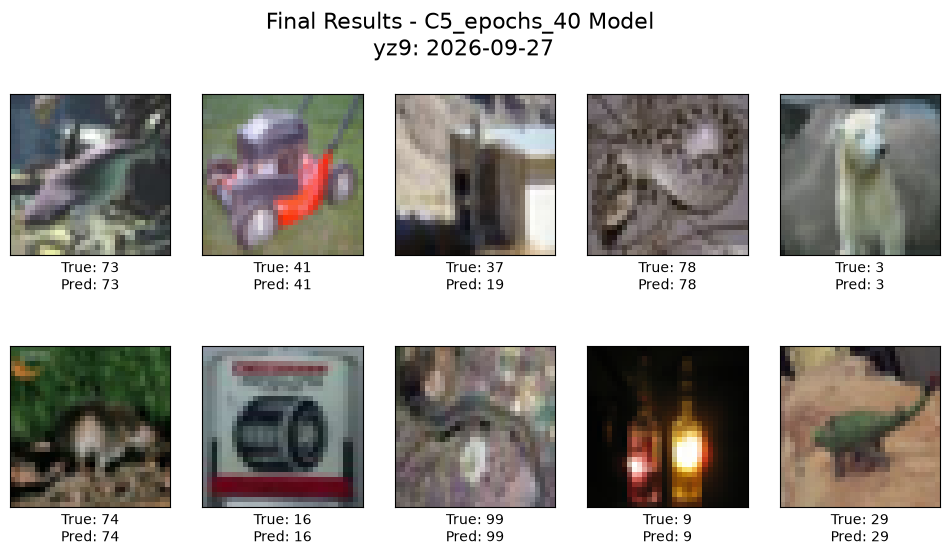

In [10]:
# Visualize the final results
visualize.visualize_images(model, testloader.dataset, device, "C5_epochs_40 Model")